In [7]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load CSV from URL
url = 'https://raw.githubusercontent.com/egorpol/beat_it/refs/heads/main/csv/dufour_onsets_aubio.csv'
df = pd.read_csv(url)

onset_times = df['onset_times'].tolist()

# Step 3: Display the first few rows of the DataFrame
display(df)


,onset_times
0,0.047778
1,0.111610
2,0.147574
3,0.202630
4,0.259138
...,...
315,69.283469
316,69.626667
317,69.647619
318,69.748662


In [8]:
from py_scripts.onset_pattern_filter import filter_onset_patterns
import numpy as np

# You already have onset_times from your previous cell
# Single-interval example:
looping_seqs = filter_onset_patterns(onset_times, pattern=2.23, tolerance=0.1, loop=True)
print("Looping-based matches (sequence, score):")
for seq, score in looping_seqs:
    print(f"Score: {score:.5f}\nSequence: {np.round(seq, 3)}\n")

fixed_pattern = [0.5, 1.0, 0.75]
pattern_seqs = filter_onset_patterns(onset_times, pattern=fixed_pattern, tolerance=0.1, loop=False)

print("Non-looping pattern-based matches (sequence, score):")
for seq, score in pattern_seqs:
    print(f"Score: {score:.5f}\nSequence: {np.round(seq, 3)}\n")

Looping-based matches (sequence, score):
Score: 0.00213
Sequence: [ 0.415  2.643  4.803  7.027  9.355 11.557 13.715 16.026 18.252 20.427
 22.721 24.896 27.119 29.429 31.585 33.894 36.141 38.384 40.606 42.85
 45.071 47.314 49.538 51.782 53.943 56.24  58.471 60.699 62.937 65.158
 67.403 69.627]

Score: 0.00232
Sequence: [ 0.336  2.643  4.803  7.027  9.355 11.557 13.715 16.026 18.252 20.427
 22.721 24.896 27.119 29.429 31.585 33.894 36.141 38.384 40.606 42.85
 45.071 47.314 49.538 51.782 53.943 56.24  58.471 60.699 62.937 65.158
 67.403 69.627]

Score: 0.00247
Sequence: [ 0.519  2.743  4.886  7.027  9.355 11.557 13.715 16.026 18.252 20.427
 22.721 24.896 27.119 29.429 31.585 33.894 36.141 38.384 40.606 42.85
 45.071 47.314 49.538 51.782 53.943 56.24  58.471 60.699 62.937 65.158
 67.403 69.627]

Non-looping pattern-based matches (sequence, score):
Score: 0.00040
Sequence: [63.675 64.145 65.158 65.897]

Score: 0.00040
Sequence: [43.587 44.057 45.071 45.81 ]

Score: 0.00044
Sequence: [39.12 

In [9]:
# Take the best (first) sequence:
best_seq, best_score = pattern_seqs[0]

print(f"Best fit score: {best_score:.5f}")
print("Onset times in best sequence:", best_seq)


Best fit score: 0.00040
Onset times in best sequence: [63.67482993 64.14503401 65.15827664 65.89671202]


In [10]:
# Save selected sequence as CSV

import os

# 1. Define the filename
filename = "best_sequence.csv"

# 2. Save the array to the CSV file
np.savetxt(filename, best_seq, delimiter=",")

# 3. Get the full, absolute path of the file
full_path = os.path.abspath(filename)

# 4. Print the confirmation message with the full path
print(f"The best sequence has been saved to: {full_path}")

The best sequence has been saved to: c:\Users\egorp\Nextcloud\code\public_repos\beat_it\best_sequence.csv


Loading BokehJS ...

Loaded 'examples_audio/Dufour_full_mono.aif' -> 77.67s @ 44100Hz


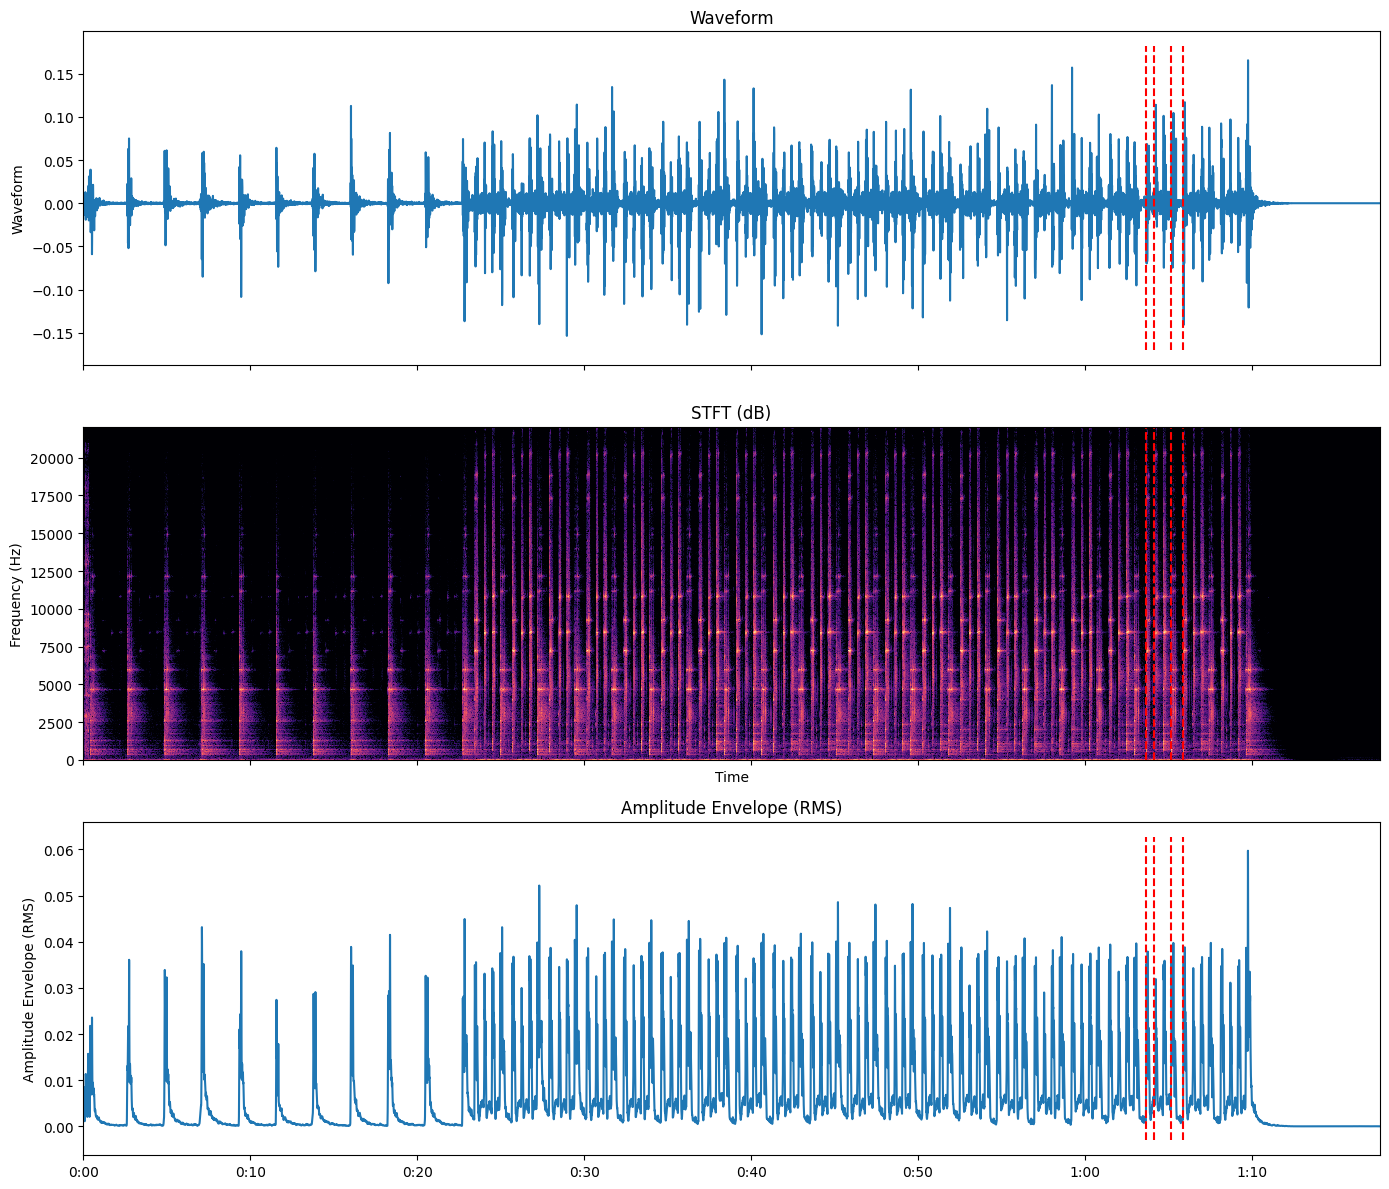

In [ ]:
# Import the functions from your updated module
from py_scripts.audio_visualizer import load_audio, extract_features, visualize_features
import numpy as np

# --- BOKEH SETUP ---
# Import the necessary function to configure Bokeh for inline notebook display
from bokeh.io import output_notebook

# Call this function ONCE at the start of your script to enable inline plotting
output_notebook()
# --- END BOKEH SETUP ---

# --- CONFIGURATION ---
AUDIO_PATH = 'examples_audio/Dufour_full_mono.aif'
HOP_LENGTH = 128
N_FFT = 2048

# Features: 'waveform', 'stft_db', 'spec_db', 'amplitude_envelope', 'zero_crossing_rate', 
# 'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
# 'melspectrogram', 'rms_low', 'rms_mid', 'rms_high'

# --- SCRIPT EXECUTION ---

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH)

# 2. Extract all necessary features at once
features = extract_features(y, sr, hop_length=HOP_LENGTH, n_fft=N_FFT)

# Pick out the best‐fitting onset times:
best_seq, best_score = pattern_seqs[0]

# Tell visualize_features which features you want to see:
FEATURES_TO_PLOT = ['waveform', 'stft_db', 'amplitude_envelope']

# Plot it (use matplotlib or bokeh)
visualize_features(
    features=features,
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=best_seq,               # <-- your filtered times here
    features_to_plot=FEATURES_TO_PLOT,
    backend='matplotlib'            
)